 ID          Опис  Кут θ₀ (°) Результат
  1  Базовий кейс         5.0 Стабільна
  2  Середній кут        12.0 Стабільна
  3 Граничний кут        20.0 Стабільна


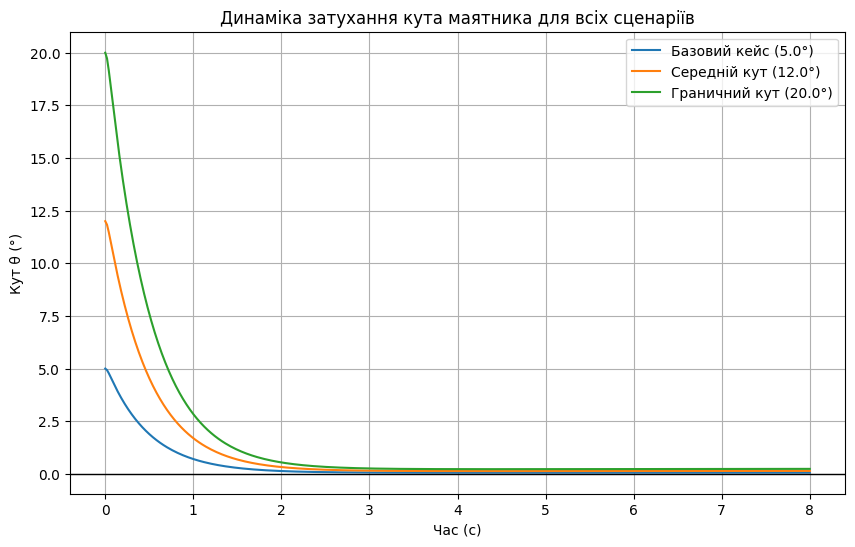

In [14]:
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# 1. Фізичні параметри системи
M, m, l, b, g = 1.0, 0.1, 0.5, 0.1, 9.81

def pendulum_eom(theta, theta_dot, F, x_dot):
    sin_th, cos_th = np.sin(theta), np.cos(theta)
    return (g * sin_th * (M + m) - (-F + m * l * theta_dot**2 * sin_th - b * x_dot) * cos_th) / (l * (M + m * sin_th**2))

def cart_eom(theta, theta_dot, F, x_dot):
    sin_th, cos_th = np.sin(theta), np.cos(theta)
    return (-F + m * l * theta_dot**2 * sin_th - m * g * sin_th * cos_th - b * x_dot) / (M + m * sin_th**2)

class PID:
    def __init__(self):
        # Перевірені коефіцієнти для стабілізації
        self.Kp, self.Kd = 60.0, 25.0 
    
    def get_force(self, state):
        x, x_dot, theta, theta_dot = state
        # PD-регулятор стабілізації кута
        F = -(self.Kp * theta + self.Kd * theta_dot)
        return np.clip(F, -100, 100)

# 2. Розрахунок усіх сценаріїв
scenarios = [
    {"id": 1, "desc": "Базовий кейс", "th0": 5.0},
    {"id": 2, "desc": "Середній кут", "th0": 12.0},
    {"id": 3, "desc": "Граничний кут", "th0": 20.0}
]

results = []
plt.figure(figsize=(10, 6))

for s in scenarios:
    pid = PID()
    def sys_rhs(t, state):
        F = pid.get_force(state)
        return [state[1], cart_eom(state[2], state[3], F, state[1]),
                state[3], pendulum_eom(state[2], state[3], F, state[1])]
    
    sol = solve_ivp(sys_rhs, (0, 8), [0.0, 0.0, np.radians(s["th0"]), 0.0], method='RK45', t_eval=np.linspace(0, 8, 400))
    
    # Критерій стабільності: кут в кінці менше 5 градусів
    is_stable = np.abs(np.degrees(sol.y[2][-1])) < 5.0
    results.append({"ID": s["id"], "Опис": s["desc"], "Кут θ₀ (°)": s["th0"], "Результат": "Стабільна" if is_stable else "Нестабільна"})
    
    # Візуалізація для звіту
    plt.plot(sol.t, np.degrees(sol.y[2]), label=f"{s['desc']} ({s['th0']}°)")

# 3. Вивід результатів
print(pd.DataFrame(results).to_string(index=False))

plt.title("Динаміка затухання кута маятника для всіх сценаріїв")
plt.xlabel("Час (с)")
plt.ylabel("Кут θ (°)")
plt.axhline(0, color='black', lw=1)
plt.grid(True)
plt.legend()
plt.show()